In [1]:
# ============================================================
# Celda 1 — Configuración e imports
# ============================================================
%matplotlib inline
import os
import requests
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import mplfinance as mpf

TICKERS = [
    "WALMEX.MX",
    "AC.MX",
    "NVDA",
    "AAPL",
    "CEMEXCPO.MX",
]

FECHA_INICIO = "2015-01-01"
FECHA_FIN = None  # None = hasta hoy


plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
import os
print(os.environ.get("BANXICO_TOKEN"))

None


In [3]:
# ============================================================
# Celda 2 — Descarga de datos OHLCV + rendimientos (una sola vez, sin duplicar)
# ============================================================
def descargar_datos(ticker, start, end=None):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df.empty:
        print(f"⚠️ {ticker}: sin datos, revisa el ticker o el rango de fechas")
        return None, None, None

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()

    precios_cierre = df["Close"]
    rendimientos = np.log(precios_cierre / precios_cierre.shift(1)).dropna()
    rendimientos.name = ticker

    if len(rendimientos) < 30:
        print(f"⚠️ {ticker}: solo {len(rendimientos)} observaciones, revisa el ticker/fechas")

    return df, precios_cierre, rendimientos


datos_ohlcv, precios, rendimientos = {}, {}, {}

for ticker in TICKERS:
    df, p, r = descargar_datos(ticker, FECHA_INICIO, FECHA_FIN)
    if df is not None:
        datos_ohlcv[ticker] = df
        precios[ticker] = p
        rendimientos[ticker] = r
        print(f"{ticker}: {len(df)} filas")

WALMEX.MX: 2936 filas
AC.MX: 2936 filas
NVDA: 2936 filas
AAPL: 2936 filas
CEMEXCPO.MX: 2936 filas


In [4]:
# ============================================================
# Celda 3 — Función de descriptivos (definida una sola vez)
# ============================================================
def descriptivos(serie):
    return pd.Series({
        "Media": serie.mean(),
        "Mediana": serie.median(),
        "Varianza": serie.var(),
        "Desviación Estándar": serie.std(),
        "Mínimo": serie.min(),
        "Máximo": serie.max(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "Asimetría": stats.skew(serie),
        "Curtosis": stats.kurtosis(serie, fisher=False),
    })

In [5]:
# ============================================================
# Celda 4 — Tabla de descriptivos, todos los tickers
# ============================================================
tabla_descriptivos = pd.DataFrame({
    ticker: descriptivos(r) for ticker, r in rendimientos.items()
})
tabla_descriptivos.round(6)

,WALMEX.MX,AC.MX,NVDA,AAPL,CEMEXCPO.MX
Media,0.000277,0.000381,0.002102,0.000880,0.000136
Mediana,0.000260,0.000158,0.002556,0.001000,0.000000
Varianza,0.000251,0.000189,0.000909,0.000328,0.000535
Desviación Estándar,0.015833,0.013766,0.030154,0.018098,0.023131
Mínimo,-0.086894,-0.069152,-0.207712,-0.137708,-0.095795
Máximo,0.083909,0.068407,0.260876,0.142617,0.127465
Q1,-0.009038,-0.007645,-0.012746,-0.007353,-0.012658
Q3,0.009457,0.008024,0.017499,0.009958,0.012335
Asimetría,-0.019566,0.200940,0.138749,-0.119250,0.309386
Curtosis,5.085912,4.895590,9.831264,9.199759,5.511404


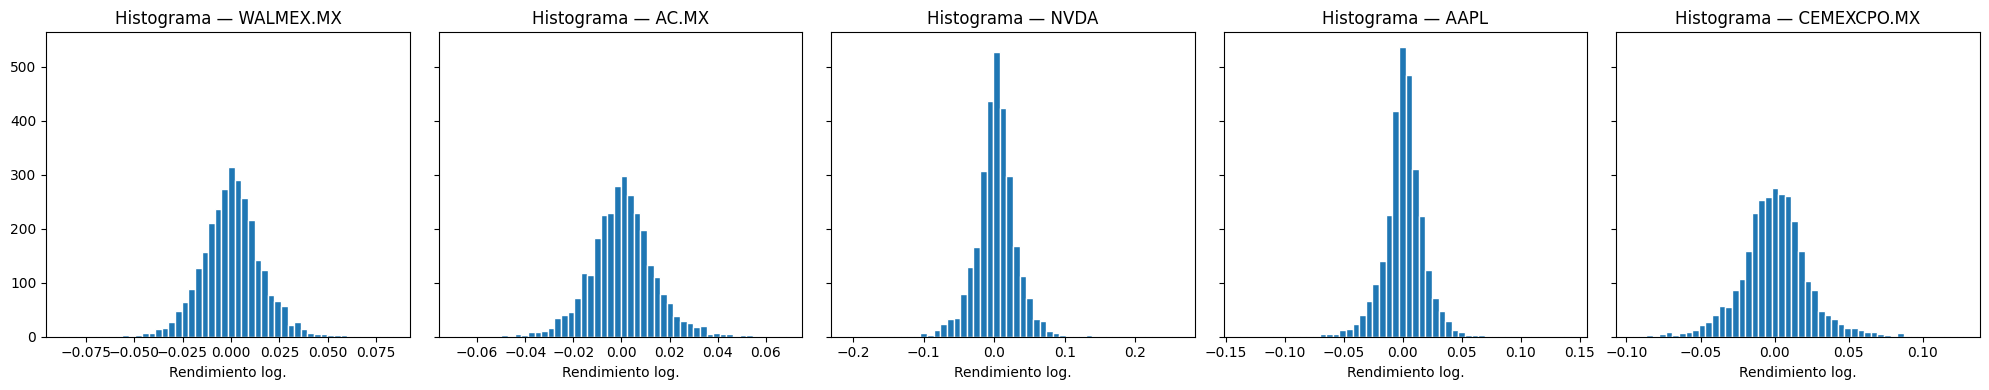

In [6]:
# ============================================================
# Celda 5 — Histogramas: una fila, N columnas (todos los tickers)
# ============================================================
n = len(rendimientos)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, ticker in zip(axes, rendimientos.keys()):
    ax.hist(rendimientos[ticker], bins=50, edgecolor="white")
    ax.set_title(f"Histograma — {ticker}")
    ax.set_xlabel("Rendimiento log.")

plt.tight_layout()
plt.show()

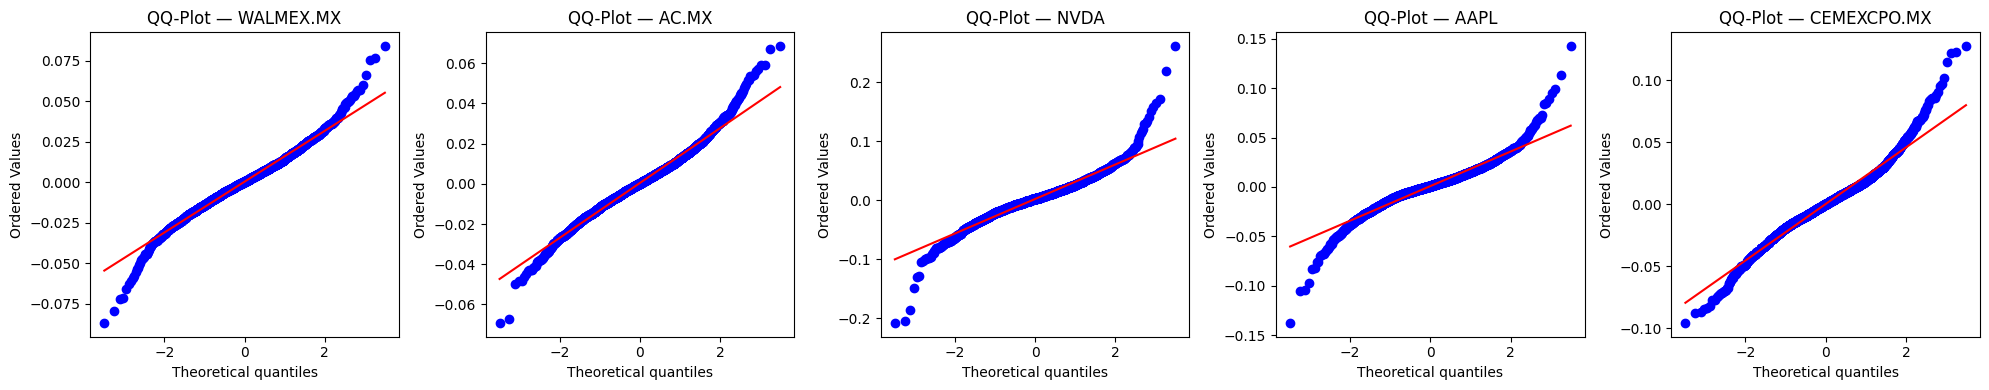

In [7]:
# ============================================================
# Celda 6 — QQ-plots: una fila, N columnas (todos los tickers)
# ============================================================
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, ticker in zip(axes, rendimientos.keys()):
    stats.probplot(rendimientos[ticker], dist="norm", plot=ax)
    ax.set_title(f"QQ-Plot — {ticker}")

plt.tight_layout()
plt.show()

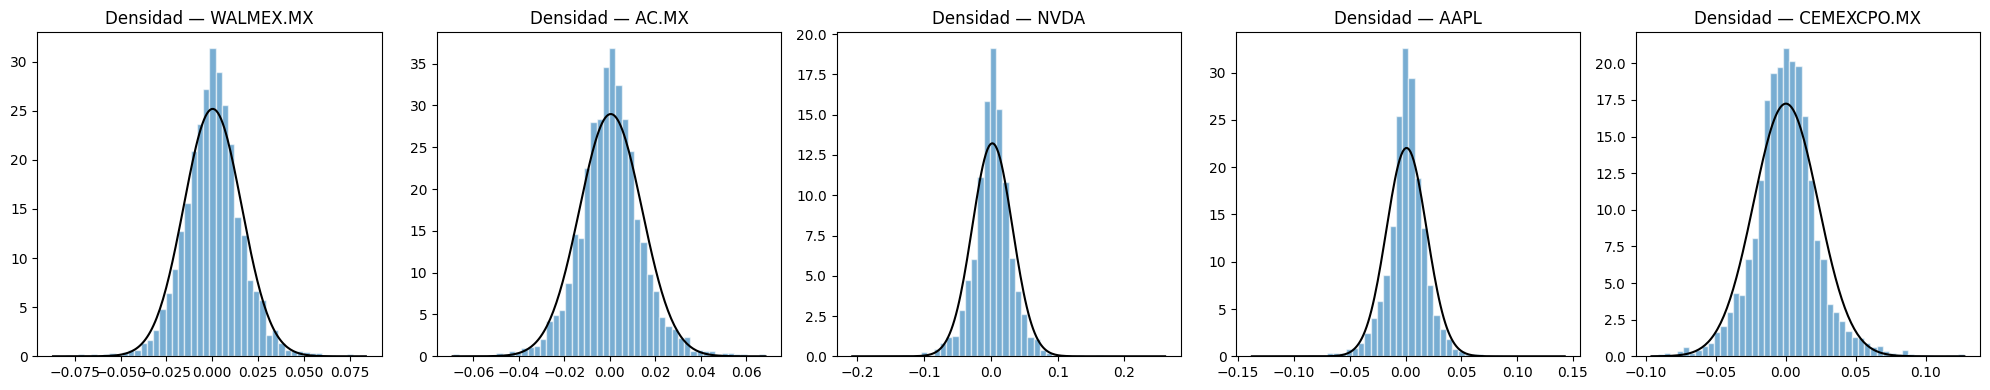

In [8]:
# ============================================================
# Celda 7 — Histograma + densidad normal ajustada: una fila, N columnas
# ============================================================
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, ticker in zip(axes, rendimientos.keys()):
    serie = rendimientos[ticker]
    ax.hist(serie, bins=50, density=True, edgecolor="white", alpha=0.6)
    mu, sigma = serie.mean(), serie.std()
    x = np.linspace(serie.min(), serie.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=1.5)
    ax.set_title(f"Densidad — {ticker}")

plt.tight_layout()
plt.show()


WALMEX.MX


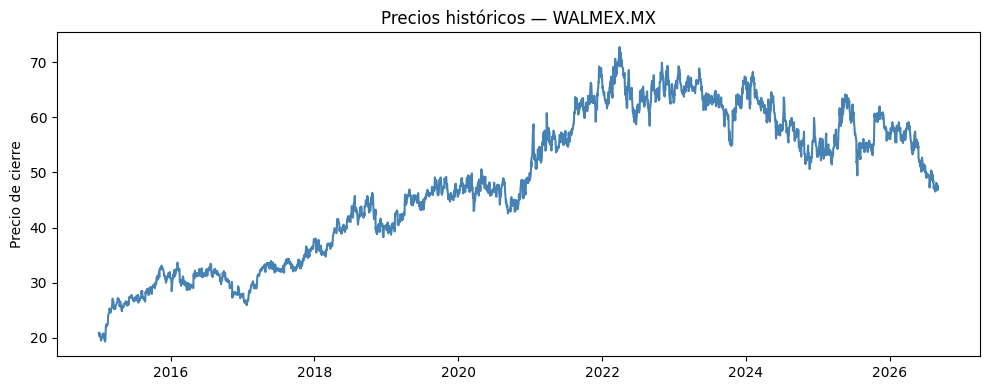

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


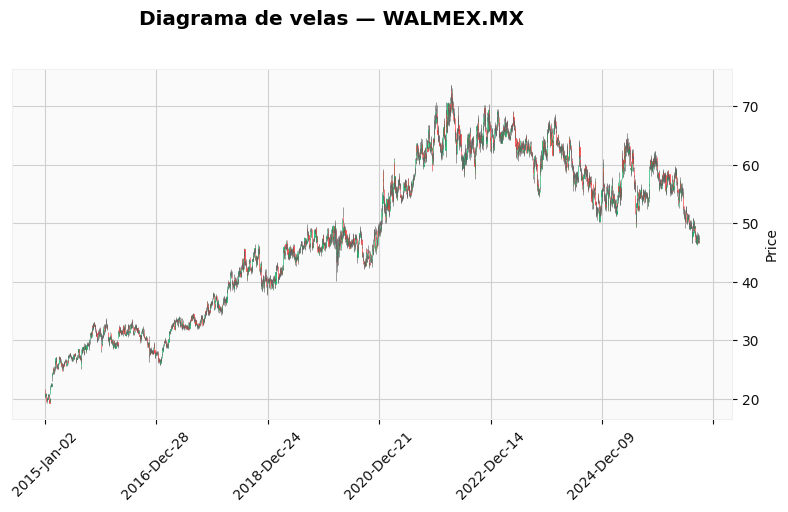

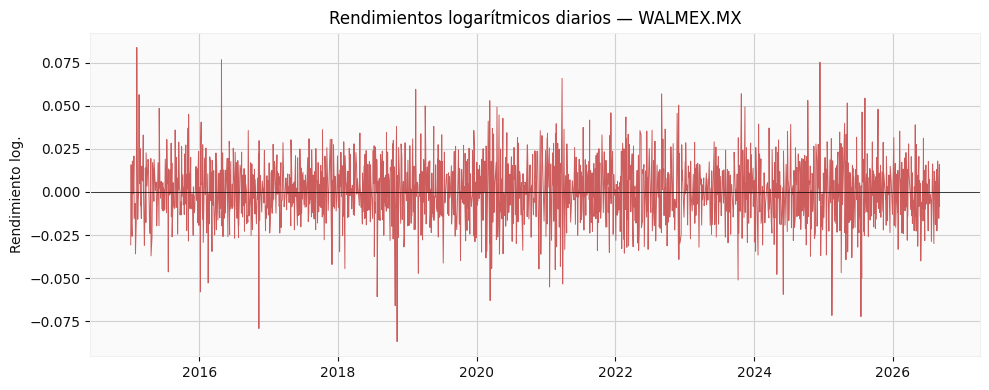


AC.MX


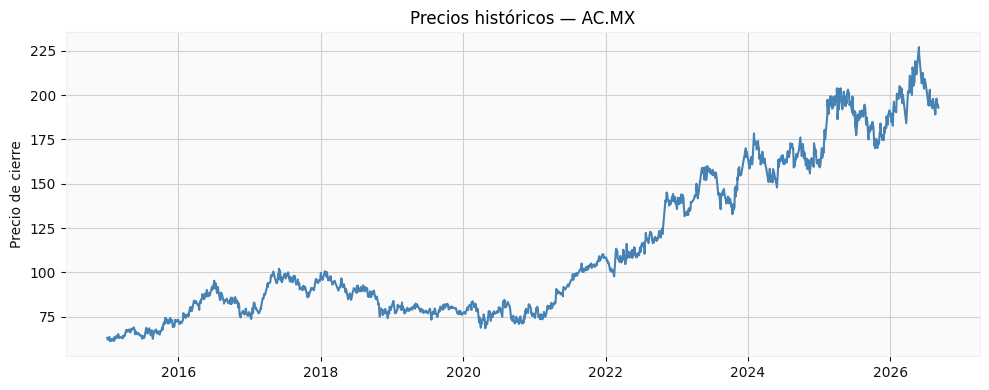

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


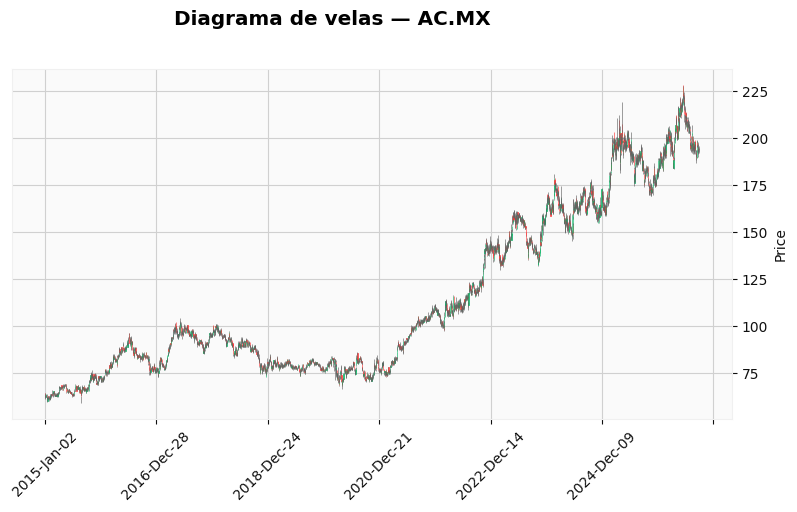

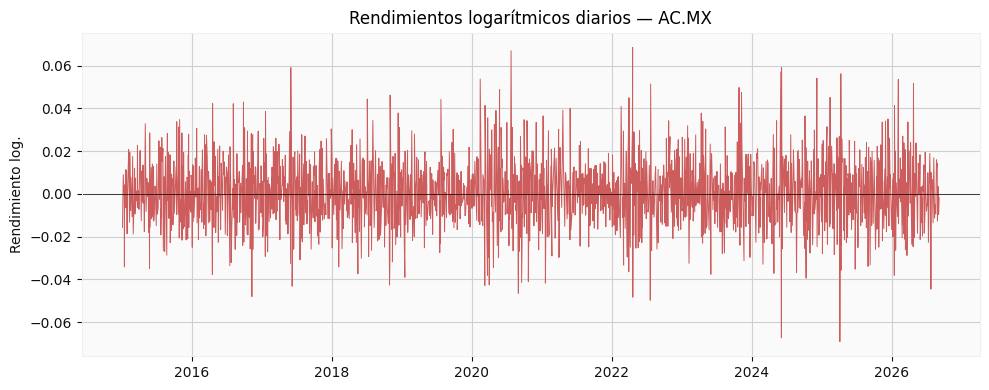


NVDA


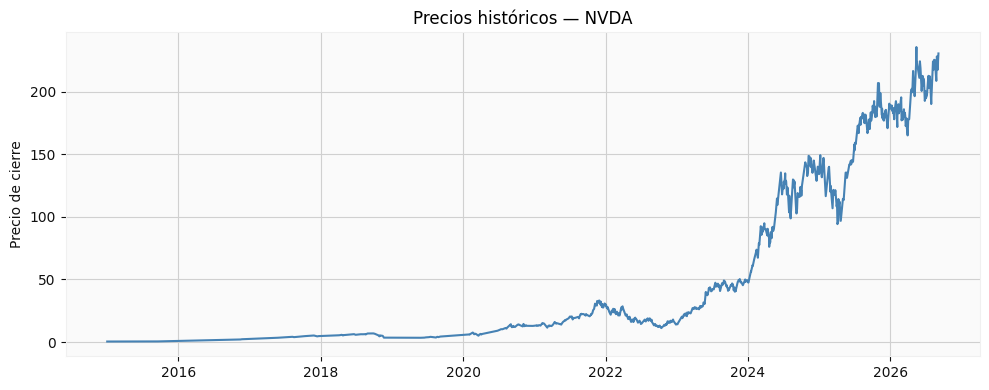

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


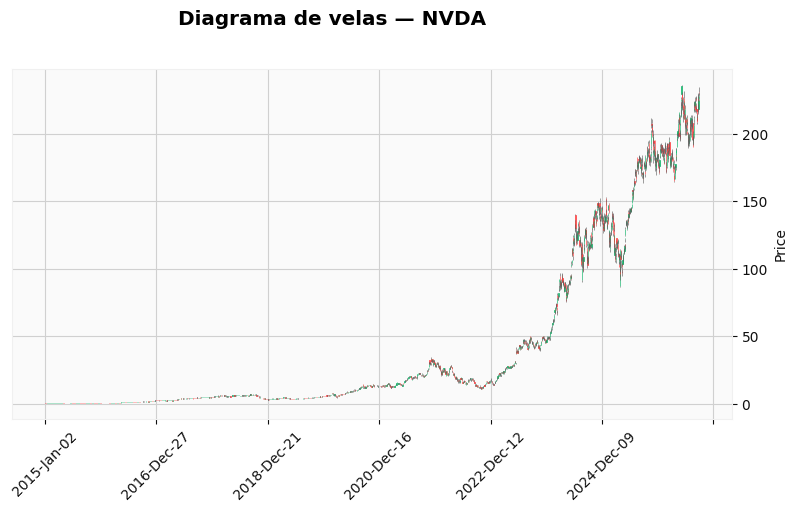

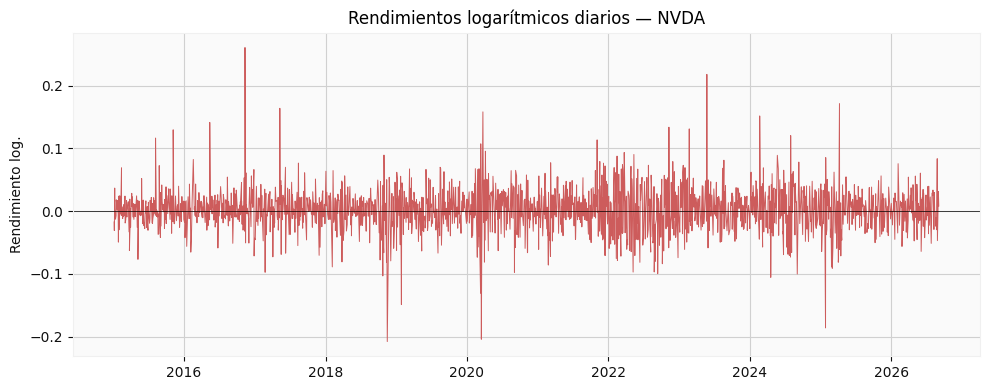


AAPL


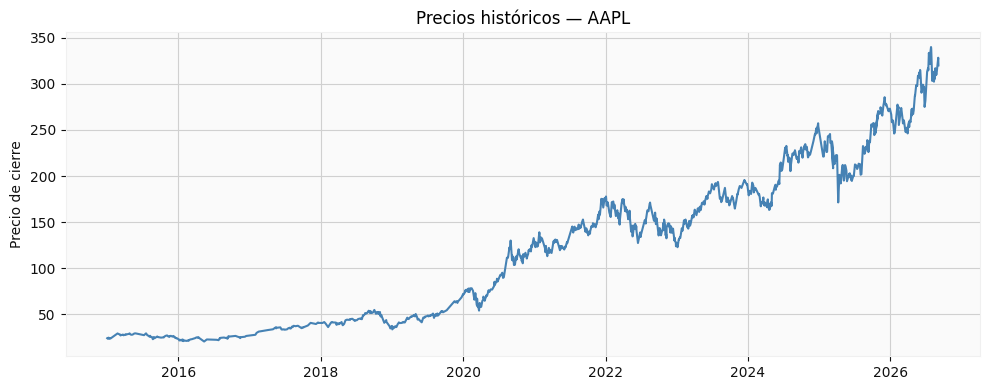

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


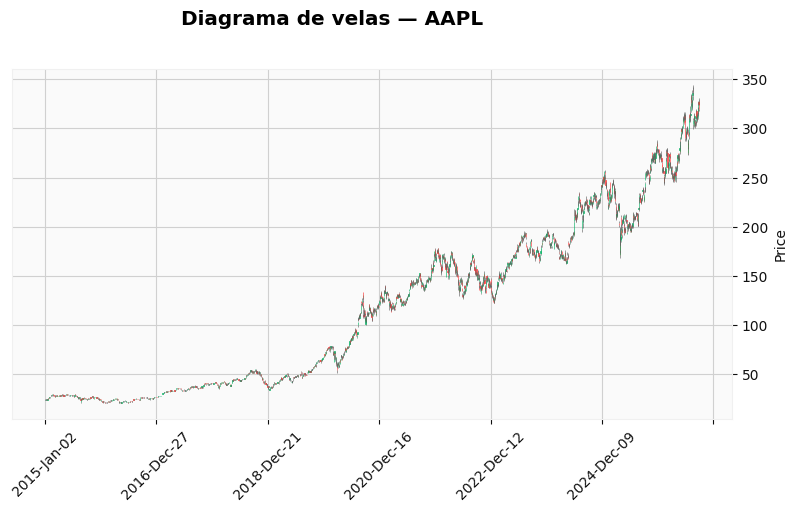

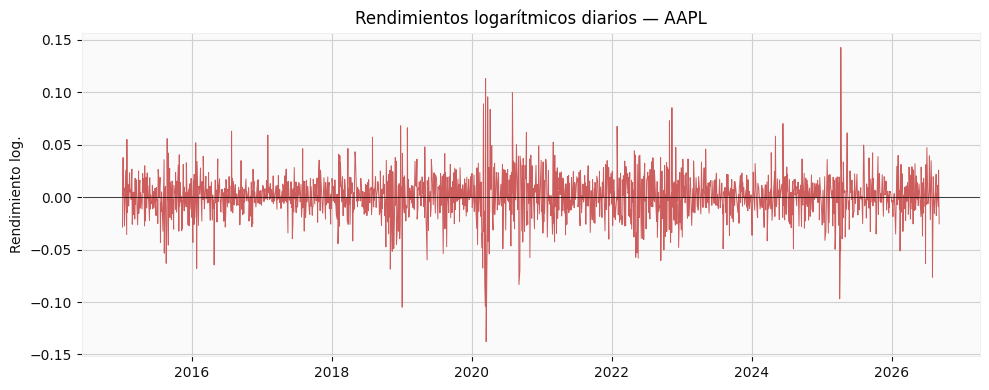


CEMEXCPO.MX


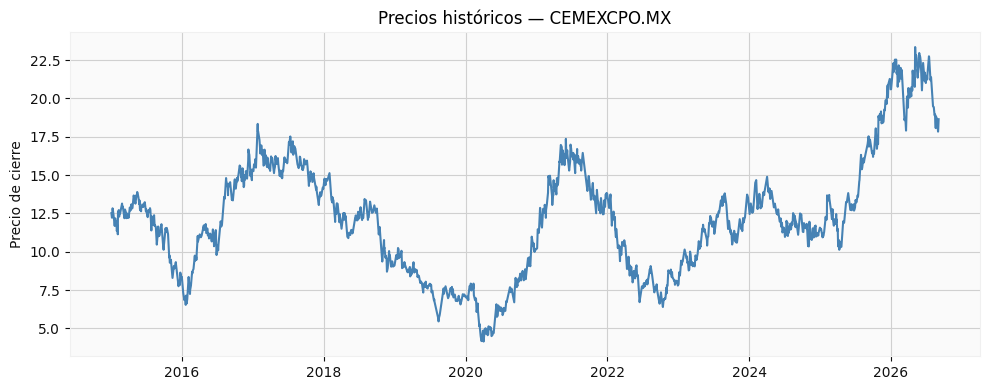

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


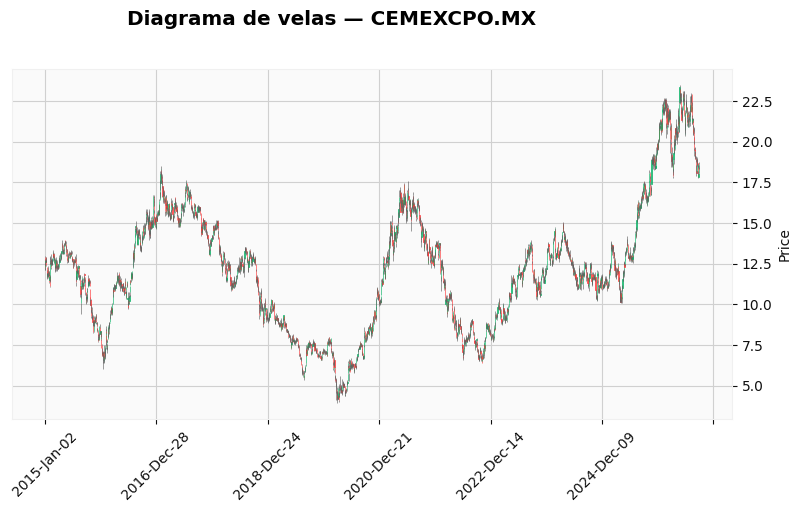

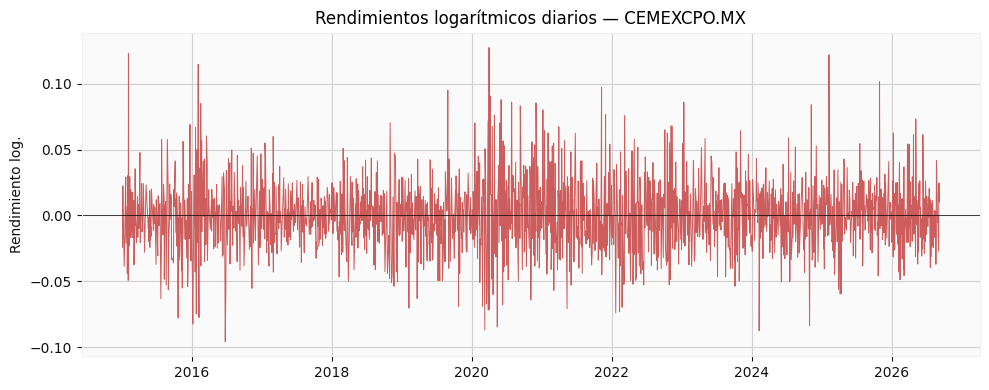

In [9]:
# ============================================================
# Celda 8 — Paquete de 3 gráficas por emisora: precios, velas, rendimientos
# ============================================================
def graficar_resumen_emisora(ticker):
    df = datos_ohlcv[ticker]
    r = rendimientos[ticker]

    # 1. Precios históricos (línea)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df["Close"], color="steelblue")
    ax.set_title(f"Precios históricos — {ticker}")
    ax.set_ylabel("Precio de cierre")
    plt.tight_layout()
    plt.show()

    # 2. Diagrama de velas
    mpf.plot(
        df,
        type="candle",
        style="yahoo",
        title=f"Diagrama de velas — {ticker}",
        volume=False,
        figsize=(10, 5),
    )

    # 3. Rendimientos históricos (línea)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(r.index, r, color="indianred", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Rendimientos logarítmicos diarios — {ticker}")
    ax.set_ylabel("Rendimiento log.")
    plt.tight_layout()
    plt.show()


for ticker in datos_ohlcv.keys():
    print(f"\n{'='*60}\n{ticker}\n{'='*60}")
    graficar_resumen_emisora(ticker)

In [10]:
# ============================================================
# Celda 9 — Selección de las dos emisoras para la sección comparativa
# ============================================================
EMISORA_1 = "CEMEXCPO.MX"   # <-- pon aquí tu primer ticker
EMISORA_2 = "AC.MX"         # <-- pon aquí tu segundo ticker

r1 = rendimientos[EMISORA_1]
r2 = rendimientos[EMISORA_2]

In [11]:
# ============================================================
# Celda 10 — Tabla de descriptivos, solo las dos emisoras (formato del capítulo)
# ============================================================
tabla = pd.DataFrame({
    EMISORA_1: descriptivos(r1),
    EMISORA_2: descriptivos(r2),
}).round(6)

tabla

,CEMEXCPO.MX,AC.MX
Media,0.000136,0.000381
Mediana,0.000000,0.000158
Varianza,0.000535,0.000189
Desviación Estándar,0.023131,0.013766
Mínimo,-0.095795,-0.069152
Máximo,0.127465,0.068407
Q1,-0.012658,-0.007645
Q3,0.012335,0.008024
Asimetría,0.309386,0.200940
Curtosis,5.511404,4.895590


In [12]:
# ============================================================
# Celda 11 — Exportar la tabla a LaTeX
# ============================================================
print(tabla.to_latex(
    caption="Descriptivos. Elaboración propia",
    label="tab:Descriptivos_emisoras",
    float_format="%.6f",
))

\begin{table}
\caption{Descriptivos. Elaboración propia}
\label{tab:Descriptivos_emisoras}
\begin{tabular}{lrr}
\toprule
 & CEMEXCPO.MX & AC.MX \\
\midrule
Media & 0.000136 & 0.000381 \\
Mediana & 0.000000 & 0.000158 \\
Varianza & 0.000535 & 0.000189 \\
Desviación Estándar & 0.023131 & 0.013766 \\
Mínimo & -0.095795 & -0.069152 \\
Máximo & 0.127465 & 0.068407 \\
Q1 & -0.012658 & -0.007645 \\
Q3 & 0.012335 & 0.008024 \\
Asimetría & 0.309386 & 0.200940 \\
Curtosis & 5.511404 & 4.895590 \\
\bottomrule
\end{tabular}
\end{table}



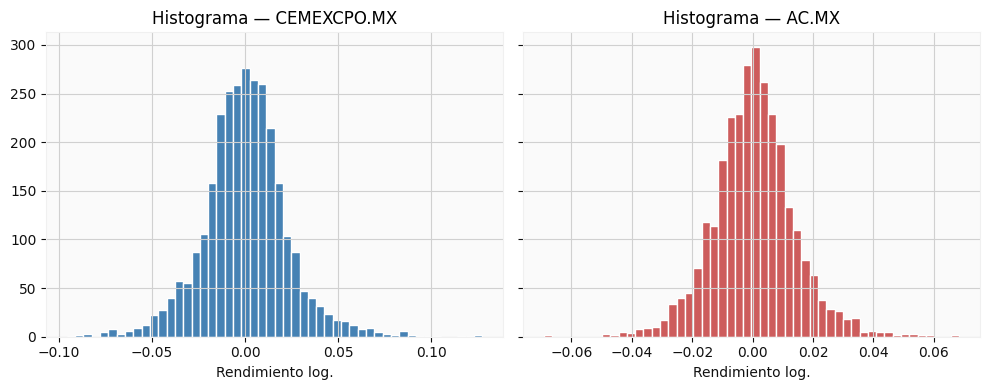

In [13]:
# ============================================================
# Celda 12 — Histogramas de ambas emisoras, lado a lado
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(r1, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title(f"Histograma — {EMISORA_1}")
axes[0].set_xlabel("Rendimiento log.")

axes[1].hist(r2, bins=50, color="indianred", edgecolor="white")
axes[1].set_title(f"Histograma — {EMISORA_2}")
axes[1].set_xlabel("Rendimiento log.")

plt.tight_layout()
plt.show()

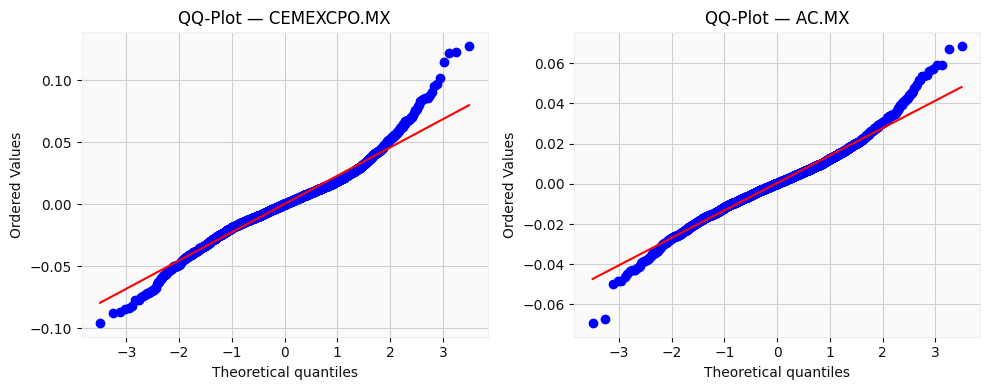

In [14]:
# ============================================================
# Celda 13 — QQ-plots de ambas emisoras, lado a lado
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

stats.probplot(r1, dist="norm", plot=axes[0])
axes[0].set_title(f"QQ-Plot — {EMISORA_1}")

stats.probplot(r2, dist="norm", plot=axes[1])
axes[1].set_title(f"QQ-Plot — {EMISORA_2}")

plt.tight_layout()
plt.show()

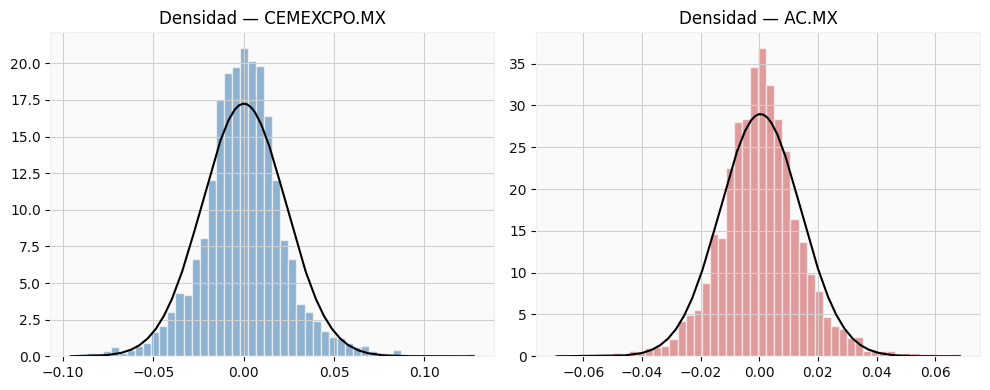

In [15]:
# ============================================================
# Celda 14 — Histograma + densidad normal ajustada, ambas emisoras
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, serie, ticker, color in zip(axes, [r1, r2], [EMISORA_1, EMISORA_2], ["steelblue", "indianred"]):
    ax.hist(serie, bins=50, density=True, color=color, edgecolor="white", alpha=0.6)
    mu, sigma = serie.mean(), serie.std()
    x = np.linspace(serie.min(), serie.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=1.5)
    ax.set_title(f"Densidad — {ticker}")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Celda 15 — Tasa libre de riesgo (Banxico API, token vía variable de entorno)
# ============================================================
# En terminal, antes de abrir el notebook:
#   export BANXICO_TOKEN="tu_token_aqui"

BANXICO_TOKEN = os.environ.get("BANXICO_TOKEN")
SERIE_CETES28 = "SF43936"  # CETES a 28 días, tasa de rendimiento

if BANXICO_TOKEN is None:
    # Respaldo manual si no está configurada la variable de entorno
    r_anual = 0.105  # <-- reemplaza con la tasa CETES 28 días vigente
    print(f"⚠️ BANXICO_TOKEN no configurado, usando valor manual: {r_anual:.4%} anual")
else:
    url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{SERIE_CETES28}/datos/oportuno"
    headers = {"Bmx-Token": BANXICO_TOKEN}

    resp = requests.get(url, headers=headers)
    resp.raise_for_status()
    dato = resp.json()["bmx"]["series"][0]["datos"][0]

    try:
        r_anual = float(dato["dato"]) / 100
    except ValueError:
        raise ValueError(f"Banxico no regresó un valor numérico: {dato['dato']}")

    print(f"CETES 28 días al {dato['fecha']}: {r_anual:.4%} anual")

r_diario = r_anual / 252
print(f"Tasa libre de riesgo diaria: {r_diario:.6%}")

⚠️ BANXICO_TOKEN no configurado, usando valor manual: 10.5000% anual
Tasa libre de riesgo diaria: 0.041667%


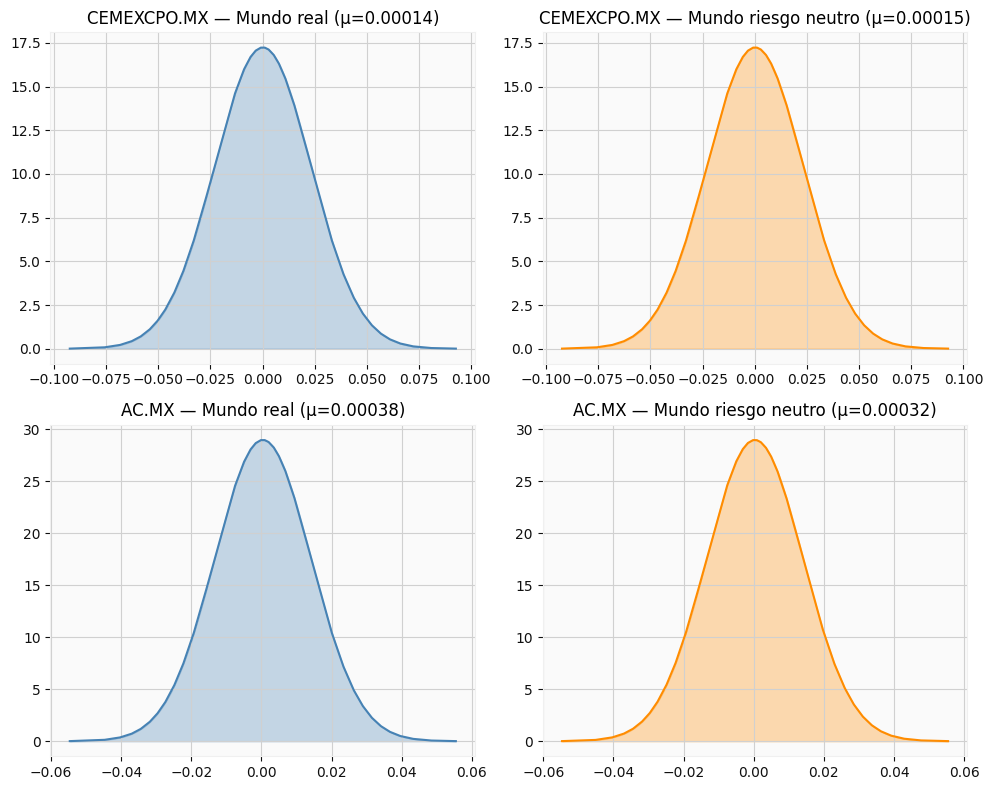

In [17]:
# ============================================================
# Celda 16 — Densidades: mundo real vs. mundo riesgo neutro, por emisora
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for fila, (ticker, serie) in enumerate(zip([EMISORA_1, EMISORA_2], [r1, r2])):
    mu_real = serie.mean()
    sigma = serie.std()
    mu_rn = r_diario - 0.5 * sigma**2

    x = np.linspace(mu_real - 4*sigma, mu_real + 4*sigma, 300)

    axes[fila, 0].plot(x, stats.norm.pdf(x, mu_real, sigma), color="steelblue")
    axes[fila, 0].fill_between(x, stats.norm.pdf(x, mu_real, sigma), alpha=0.3, color="steelblue")
    axes[fila, 0].set_title(f"{ticker} — Mundo real (μ={mu_real:.5f})")

    axes[fila, 1].plot(x, stats.norm.pdf(x, mu_rn, sigma), color="darkorange")
    axes[fila, 1].fill_between(x, stats.norm.pdf(x, mu_rn, sigma), alpha=0.3, color="darkorange")
    axes[fila, 1].set_title(f"{ticker} — Mundo riesgo neutro (μ={mu_rn:.5f})")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Celda 17 — Parámetros de simulación
# ============================================================
T = 1.0        # vencimiento en años
n_pasos = 252  # pasos de tiempo (uno por día hábil)
n_trayectorias = 100_000

dt = T / n_pasos

In [19]:
# ============================================================
# Celda 18 — Simulación de trayectorias GBM bajo la medida neutral al riesgo
# ============================================================
def simular_trayectorias_gbm(S0, sigma, r, T, n_pasos, n_trayectorias, seed=None):
    dt = T / n_pasos
    rng = np.random.default_rng(seed)

    Z = rng.standard_normal((n_trayectorias, n_pasos))
    incrementos = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    log_S = np.log(S0) + np.cumsum(incrementos, axis=1)
    log_S = np.hstack([np.full((n_trayectorias, 1), np.log(S0)), log_S])

    return np.exp(log_S)

In [20]:
# ============================================================
# Celda 19 — Parámetros por emisora y simulación (semillas distintas)
# ============================================================
S0_1 = precios[EMISORA_1].iloc[-1]
S0_2 = precios[EMISORA_2].iloc[-1]

sigma_1 = r1.std() * np.sqrt(252)
sigma_2 = r2.std() * np.sqrt(252)

r_libre_riesgo = r_anual

trayectorias_1 = simular_trayectorias_gbm(S0_1, sigma_1, r_libre_riesgo, T, n_pasos, n_trayectorias, seed=42)
trayectorias_2 = simular_trayectorias_gbm(S0_2, sigma_2, r_libre_riesgo, T, n_pasos, n_trayectorias, seed=123)

print(f"{EMISORA_1}: S0={S0_1:.2f}, σ={sigma_1:.4f}")
print(f"{EMISORA_2}: S0={S0_2:.2f}, σ={sigma_2:.4f}")

CEMEXCPO.MX: S0=18.64, σ=0.3672
AC.MX: S0=192.96, σ=0.2185


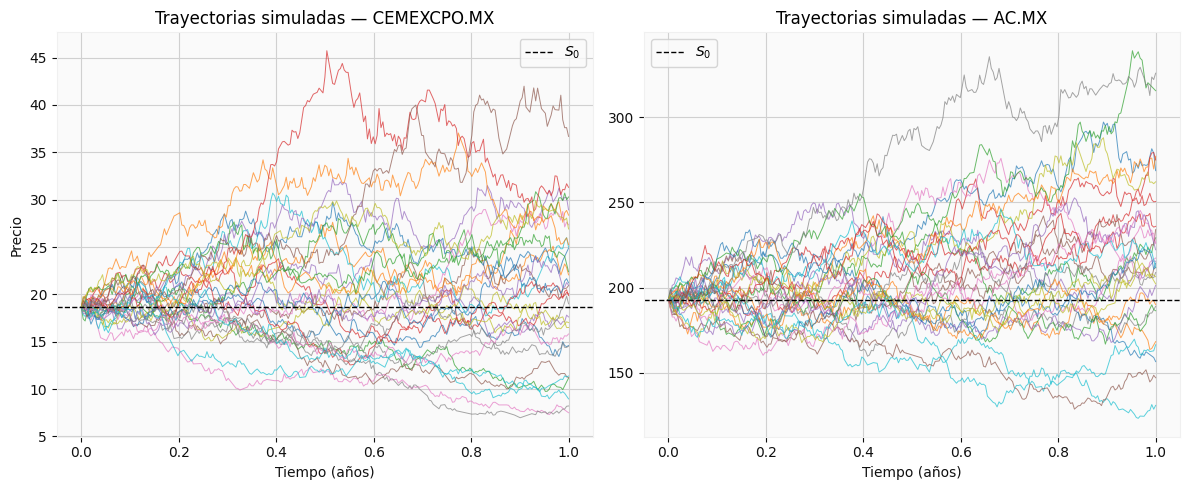

In [21]:
# ============================================================
# Celda 20 — Gráfica: algunas trayectorias simuladas, ambas emisoras
# ============================================================
n_mostrar = 30
ejes_tiempo = np.linspace(0, T, n_pasos + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for i in range(n_mostrar):
    axes[0].plot(ejes_tiempo, trayectorias_1[i], linewidth=0.7, alpha=0.7)
axes[0].axhline(S0_1, color="black", linestyle="--", linewidth=1, label="$S_0$")
axes[0].set_title(f"Trayectorias simuladas — {EMISORA_1}")
axes[0].set_xlabel("Tiempo (años)")
axes[0].set_ylabel("Precio")
axes[0].legend()

for i in range(n_mostrar):
    axes[1].plot(ejes_tiempo, trayectorias_2[i], linewidth=0.7, alpha=0.7)
axes[1].axhline(S0_2, color="black", linestyle="--", linewidth=1, label="$S_0$")
axes[1].set_title(f"Trayectorias simuladas — {EMISORA_2}")
axes[1].set_xlabel("Tiempo (años)")
axes[1].legend()

plt.tight_layout()
plt.show()